# Diffraction Image Analysis Toolkit

A small toolkit for working with X-ray diffraction (XRD) detector images.

**What this notebook does, end to end:**
1. Load a TIFF detector image and scale it for display (pyFAI-style).
2. Find the **beam center** (where the diffraction rings are centered).
3. Predict **single-crystal diffraction spots** from a crystal structure (`.cif`) file.
4. **Overlay** predicted rings onto the real image to identify which spots come from the substrate vs. the film.

**Notebook layout**
- Section 0 — Setup & imports
- Section 1 — Mount Google Drive
- Section 2 — Data file paths
- Section 3 — Function library (loader, two center-finders, ring overlay)
- Section 4 — Find the beam center (powder sample)
- Section 5 — Loading example & output shapes
- Section 6 — Predicted single-crystal spots from a CIF
- Section 7 — Overlay predicted rings on the image
- Section 8 — Extra / unused utilities


## 0. Setup & Imports

Install the third-party packages and import everything used throughout the
notebook in one place, so later cells stay focused on the analysis.


In [1]:
# Third-party packages (TIFF reading + crystallography)
!pip install tifffile gemmi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 30.4 MB/s eta 0:00:00


In [2]:
# Standard library
import os
import re
import math
from itertools import product
from collections import defaultdict

# Scientific stack
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tifffile
import gemmi

from scipy.ndimage import gaussian_filter, sobel
from scipy.optimize import minimize


## 1. Mount Google Drive

The image and CIF files live in a shared Drive folder. Create a **shortcut**
to that shared folder in your own Drive so the paths below resolve. If you
access the files another way, just edit the paths in Section 2.


datalink: https://drive.google.com/drive/u/1/folders/1RTY1fPUkWfnLAIFtACJDpRkoZwzjyx8X

In [5]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


## 2. Data File Paths

All input files referenced by the notebook. Edit these if your folder layout
differs.


In [6]:
# Folders containing the test TIFFs
data_dir = [
    '/content/drive/MyDrive/Background Removal Data Nb blank Ti/Test Tiffs/Stitched Images',
    '/content/drive/MyDrive/Background Removal Data Nb blank Ti/Test Tiffs/Wafer Images',
]

# Test images:
#   [0] powder/diffraction sum image (good clear rings -> easy center finding)
#   [1] blank (background only)
#   [2] Nb side of the wafer
#   [3] Ti side of the wafer
image_test = [
    'xrd_JS06_20260323-162040_b9dead_sum.tiff',
    'Blank.tiff',
    'Nb.tiff',
    'Ti.tiff',
]

# Crystal structure used for the single-crystal spot prediction (Section 6)
cif_file = '/content/drive/MyDrive/Background Removal Data Nb blank Ti/film.cif'


## 3. Function Library

Four reusable functions, one per cell:

| Function | Purpose |
|---|---|
| `load_and_view_tiff_pyfai` | Load a TIFF, scale it for display, and export pixel datasets. |
| `find_diffraction_center_frst` | beam-center finder via radial-symmetry voting (slower). |
| `find_diffraction_center` |  beam-center finder via radial-histogram sharpness. |
| `overlay_diffraction_rings` | Draw rings of given radii around a center on an image. |


### 3.1 Load & scale a TIFF (`load_and_view_tiff_pyfai`)

In [7]:
def load_and_view_tiff_pyfai(
    data_dir,
    filename,
    cmap='inferno',
    percentile_low=1,
    percentile_high=99.5,
    log_scale=True,
    figsize=(8, 8),
    show_plot=True,
):
    """
    Load, scale, display, and export TIFF image data (pyFAI-style).

    Returns
    -------
    image_array    : np.ndarray  - original image data
    raw_dataset    : np.ndarray  - (N, 3) array of [x, y, raw_intensity]
    scaled_dataset : np.ndarray  - (N, 3) array of [x, y, scaled_intensity]
    display_image  : np.ndarray  - 2D scaled image used for visualization
    """
    # --- Load image ---
    file_path = os.path.join(data_dir, filename)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    image_array = tifffile.imread(file_path)
    image = image_array.astype(np.float64)  # float for processing

    # --- Keep only finite pixels for the percentile stretch ---
    finite_mask = np.isfinite(image)
    if not np.any(finite_mask):
        raise ValueError("Image contains no finite values.")
    valid_pixels = image[finite_mask]

    # --- pyFAI-like scaling: clip to percentile range, shift, optional log ---
    vmin = np.percentile(valid_pixels, percentile_low)
    vmax = np.percentile(valid_pixels, percentile_high)
    if vmax <= vmin:
        vmax = vmin + 1e-9

    clipped = np.clip(image, vmin, vmax) - vmin   # clip + shift baseline to 0
    if log_scale:
        clipped = np.log1p(clipped)               # compress dynamic range

    # --- Normalize to 0-1 and clean invalid values ---
    finite_clipped = clipped[np.isfinite(clipped)]
    cmin, cmax = finite_clipped.min(), finite_clipped.max()
    display_image = (clipped - cmin) / (cmax - cmin)
    display_image = np.nan_to_num(display_image, nan=0, posinf=1, neginf=0)

    # --- Build per-pixel coordinate grids ---
    height, width = image.shape[:2]
    y_positions, x_positions = np.indices((height, width))

    # --- Flatten into [x, y, intensity] datasets ---
    raw_dataset = np.column_stack(
        (x_positions.ravel(), y_positions.ravel(), image.ravel())
    )
    scaled_dataset = np.column_stack(
        (x_positions.ravel(), y_positions.ravel(), display_image.ravel())
    )

    # --- Display ---
    if show_plot:
        plt.figure(figsize=figsize)
        plt.imshow(display_image, cmap=cmap, origin='lower')
        plt.colorbar(label='Scaled Intensity')
        plt.title(f"{filename}\nDisplay Range: [{vmin:.3g}, {vmax:.3g}]")
        plt.tight_layout()
        plt.show()

    return image_array, raw_dataset, scaled_dataset, display_image


### 3.2 center finder (`find_diffraction_center_frst`)

Radial-symmetry / gradient-voting method. Slower but reliable on incomplete
rings, partial arcs, strong intensity asymmetry, and spotty diffraction.


In [8]:
def find_diffraction_center_frst(
    display_image,
    blur_sigma=2,
    edge_percentile=94,
    line_length=200,
    show_plot=True,
    figsize=(10, 10),
):
    """
    Find the diffraction center by having edge pixels "vote" along their
    gradient direction; rays from a ring all converge on the center.

    Returns
    -------
    center_x, center_y : float
    accumulator        : np.ndarray  (vote map)
    """
    image = np.nan_to_num(np.asarray(display_image, dtype=np.float64), nan=0)

    # --- Smooth, then compute gradient magnitude (Sobel) ---
    smoothed = gaussian_filter(image, sigma=blur_sigma)
    gx = sobel(smoothed, axis=1)
    gy = sobel(smoothed, axis=0)
    grad_mag = np.sqrt(gx**2 + gy**2)

    # --- Keep only the strongest edge pixels ---
    threshold = np.percentile(grad_mag[grad_mag > 0], edge_percentile)
    mask = grad_mag >= threshold
    y_points, x_points = np.nonzero(mask)

    # --- Cast votes along each edge pixel's gradient (both directions) ---
    accumulator = np.zeros_like(image, dtype=np.float64)
    height, width = image.shape

    for y, x in zip(y_points, x_points):
        gxn, gyn = gx[y, x], gy[y, x]
        norm = np.sqrt(gxn**2 + gyn**2)
        if norm == 0:
            continue
        gxn, gyn = gxn / norm, gyn / norm

        for sign in (+1, -1):              # gradient may point in/out
            dx, dy = sign * gxn, sign * gyn
            for r in range(line_length):
                xx = int(round(x + dx * r))
                yy = int(round(y + dy * r))
                if xx < 0 or xx >= width or yy < 0 or yy >= height:
                    break
                accumulator[yy, xx] += 1

    # --- Center = brightest point in the vote map ---
    center_y, center_x = np.unravel_index(np.argmax(accumulator), accumulator.shape)

    if show_plot:
        fig, ax = plt.subplots(1, 2, figsize=(14, 7))
        ax[0].imshow(display_image, cmap='inferno', origin='lower')
        ax[0].scatter(center_x, center_y, s=300, marker='x')
        ax[0].set_title(f"Detected Center\nx={center_x}, y={center_y}")
        ax[1].imshow(accumulator, cmap='viridis', origin='lower')
        ax[1].scatter(center_x, center_y, s=300, marker='x')
        ax[1].set_title("Radial Symmetry Accumulator")
        plt.tight_layout()
        plt.show()

    return center_x, center_y, accumulator


### 3.3 Fast center finder (`find_diffraction_center`)

Optimizes the center so the radial intensity histogram is as **sharp** as
possible. Quick first pass when rings are reasonably complete.


In [9]:
def find_diffraction_center(
    display_image,
    blur_sigma=2,
    intensity_percentile=92,
    radial_bins=500,
    show_plot=True,
    figsize=(10, 10),
):
    """
    Find the ring center by maximizing radial-histogram sharpness.

    Returns
    -------
    center_x, center_y : float
    """
    image = np.nan_to_num(np.asarray(display_image, dtype=np.float64), nan=0)

    # --- Smooth and keep the brightest (ring) pixels ---
    smoothed = gaussian_filter(image, sigma=blur_sigma)
    threshold = np.percentile(smoothed[smoothed > 0], intensity_percentile)
    mask = smoothed >= threshold
    y_points, x_points = np.nonzero(mask)
    weights = smoothed[mask]

    # --- Intensity-weighted centroid as the starting guess ---
    x0 = np.average(x_points, weights=weights)
    y0 = np.average(y_points, weights=weights)

    def radial_sharpness_metric(center):
        # Correct center -> ring pixels fall into few radial bins (sharp peaks).
        xc, yc = center
        r = np.sqrt((x_points - xc)**2 + (y_points - yc)**2)
        hist, _ = np.histogram(r, bins=radial_bins, weights=weights)
        return -np.sum(hist**2)            # maximize sharpness => minimize -sharpness

    result = minimize(radial_sharpness_metric, x0=[x0, y0], method='Nelder-Mead')
    center_x, center_y = result.x

    if show_plot:
        plt.figure(figsize=figsize)
        plt.imshow(display_image, cmap='inferno', origin='lower')
        plt.scatter(center_x, center_y, s=250, marker='x')
        plt.title(f"Optimized Diffraction Center\nx = {center_x:.2f}, y = {center_y:.2f}")
        plt.colorbar(label='Scaled Intensity')
        plt.tight_layout()
        plt.show()

    return center_x, center_y


### 3.4 Overlay rings (`overlay_diffraction_rings`)

In [10]:
def overlay_diffraction_rings(
    image,
    center,
    radii,
    cmap='inferno',
    figsize=(8, 8),
    ring_color='cyan',
    ring_width=1.5,
    show_center=True,
    save_path=None,
):
    """
    Draw circles of the given pixel radii around `center` on top of `image`.

    Parameters
    ----------
    center : (x_center, y_center)
    radii  : iterable of ring radii in pixels

    Returns
    -------
    fig, ax
    """
    xc, yc = center
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image, cmap=cmap, origin='lower')

    # --- Draw each ring as a parametric circle ---
    theta = np.linspace(0, 2 * np.pi, 1000)
    for r in radii:
        ax.plot(xc + r * np.cos(theta), yc + r * np.sin(theta),
                color=ring_color, linewidth=ring_width)

    if show_center:
        ax.scatter(xc, yc, color='red', s=120, marker='x')

    ax.set_title("Diffraction Rings Overlay")
    ax.set_axis_off()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    return fig, ax


## 4. Find the Beam Center (Powder Sample)

The powder image has clean, well-defined rings, which makes it ideal for
locating the beam center. Load it, then run the robust center finder.


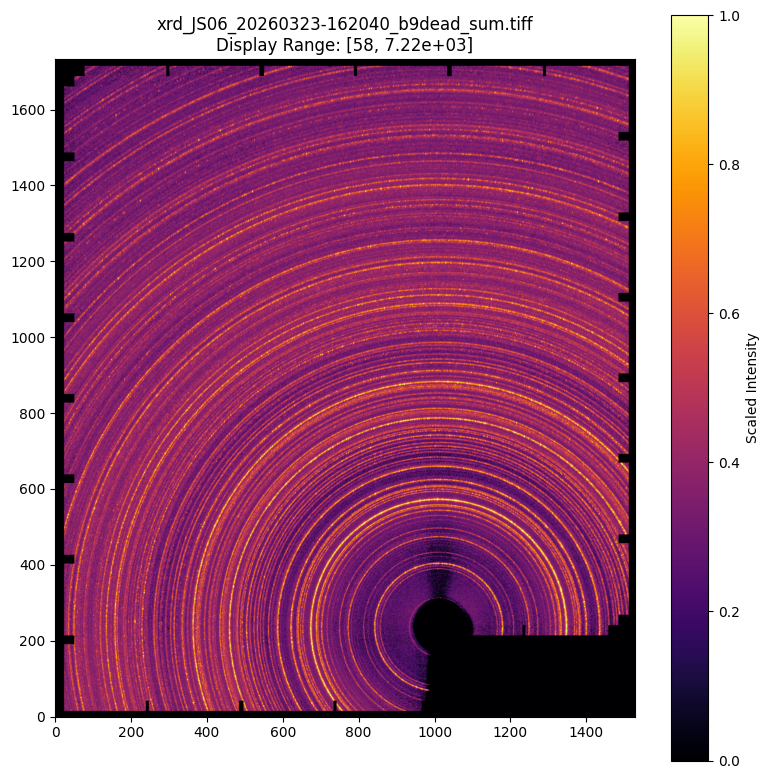

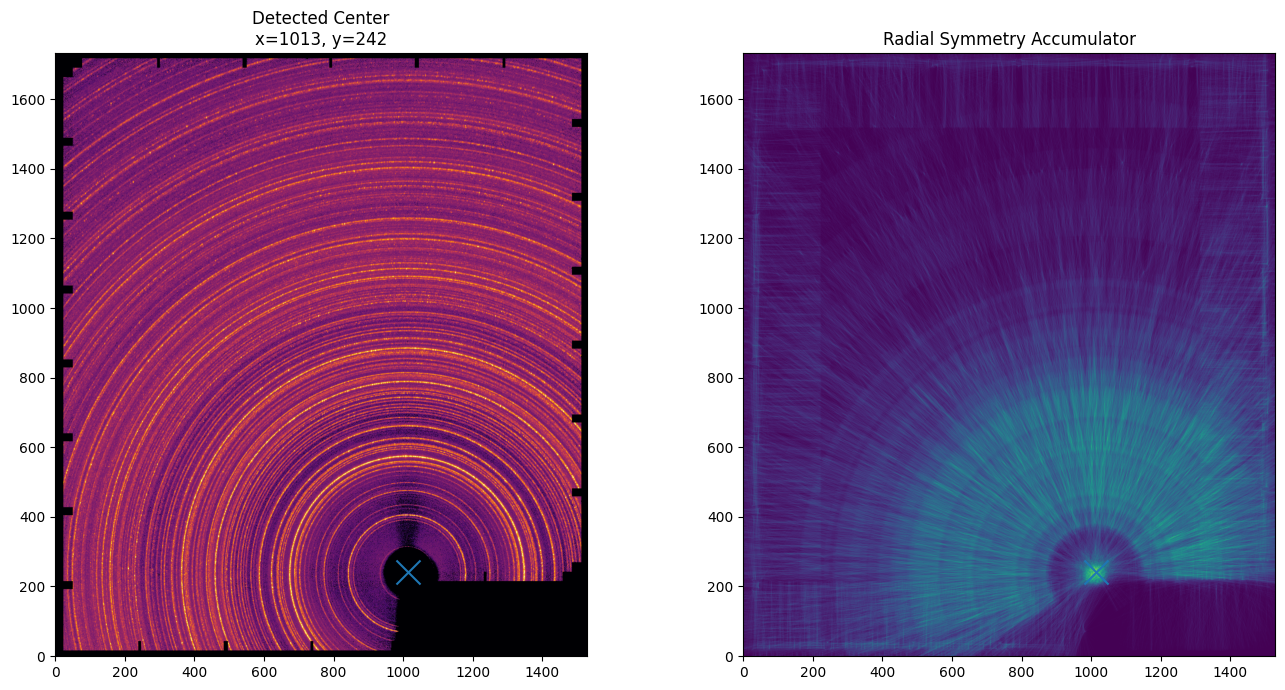

In [18]:
# Load the powder/diffraction sum image
image_array, raw_data, scaled_data, display_image = load_and_view_tiff_pyfai(
    data_dir[0],
    image_test[0],
    percentile_low=1,
    percentile_high=99.9,
)

# Locate the beam center (robust method) (appx. 4 min)
center_x, center_y, accumulator = find_diffraction_center_frst(display_image)


## 5. Loading Example & Output Shapes

Minimum input to the loader is just the directory and filename. It returns:

- `image_array`    - original image data
- `raw_dataset`    - (N, 3): `[x, y, raw_intensity]`
- `scaled_dataset` - (N, 3): `[x, y, scaled_intensity]`
- `display_image`  - 2D scaled image for visualization


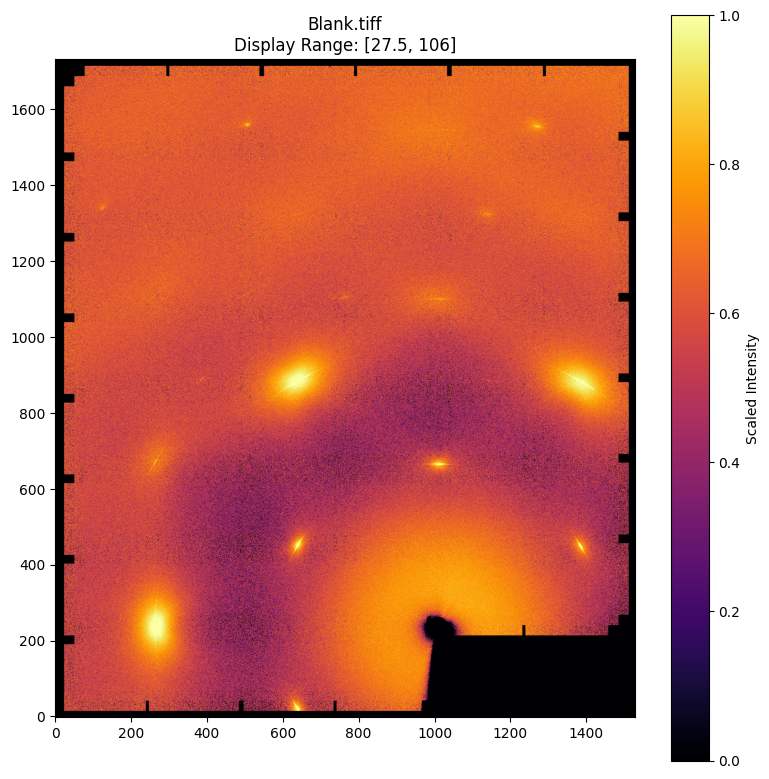

In [19]:
# Load the blank (background-only) image as a demonstration
image_array, raw_data, scaled_data, display_image = load_and_view_tiff_pyfai(
    data_dir[1],
    image_test[1],
    percentile_low=1,
    percentile_high=99.9,
)


In [20]:
# Inspect shapes and the first few rows of the exported datasets
print("image_array :", image_array.shape)
print("raw_data    :", raw_data.shape)
print("scaled_data :", scaled_data.shape)
print()
print("raw_data[:5]\n", raw_data[:5])
print("scaled_data[:5]\n", scaled_data[:5])


image_array : (1733, 1529)
raw_data    : (2649757, 3)
scaled_data : (2649757, 3)

raw_data[:5]
 [[ 0.  0. nan]
 [ 1.  0. nan]
 [ 2.  0. nan]
 [ 3.  0. nan]
 [ 4.  0. nan]]
scaled_data[:5]
 [[0. 0. 0.]
 [1. 0. 0.]
 [2. 0. 0.]
 [3. 0. 0.]
 [4. 0. 0.]]


## 6. Predicted Single-Crystal Spots (from a CIF)

Computes the geometric reflections expected for a single-crystal wafer at a
given **zone axis** (the crystal facing relative to the beam).

> **Note:** This keeps reflections that may be destroyed by destructive
> interference, so it predicts **more** spots than will actually appear. The
> visible list is curated against the observed data in Section 7.

The block is organized as: user inputs -> read CIF -> build lattices ->
loop over `hkl` (apply absences + zone-axis rule + structure factor) ->
project to detector -> group into radial shells -> plot.



Radial shells:

r ~ 42.350
  hkl: [(-1, 0, 0), (-1, 1, 0), (0, -1, 0), (0, 1, 0), (1, -1, 0), (1, 0, 0)]

r ~ 73.350
  hkl: [(-2, 1, 0), (-1, -1, 0), (-1, 2, 0), (1, -2, 0), (1, 1, 0), (2, -1, 0)]

r ~ 84.700
  hkl: [(-2, 0, 0), (-2, 2, 0), (0, -2, 0), (0, 2, 0), (2, -2, 0), (2, 0, 0)]

r ~ 112.050
  hkl: [(-3, 1, 0), (-3, 2, 0), (-2, -1, 0), (-2, 3, 0), (-1, -2, 0), (-1, 3, 0), (1, -3, 0), (1, 2, 0), (2, -3, 0), (2, 1, 0), (3, -2, 0), (3, -1, 0)]

r ~ 127.050
  hkl: [(-3, 0, 0), (-3, 3, 0), (0, -3, 0), (0, 3, 0), (3, -3, 0), (3, 0, 0)]

r ~ 146.700
  hkl: [(-4, 2, 0), (-2, -2, 0), (-2, 4, 0), (2, -4, 0), (2, 2, 0), (4, -2, 0)]

r ~ 152.700
  hkl: [(-4, 1, 0), (-4, 3, 0), (-3, -1, 0), (-3, 4, 0), (-1, -3, 0), (-1, 4, 0), (1, -4, 0), (1, 3, 0), (3, -4, 0), (3, 1, 0), (4, -3, 0), (4, -1, 0)]

r ~ 169.400
  hkl: [(-4, 0, 0), (-4, 4, 0), (0, -4, 0), (0, 4, 0), (4, -4, 0), (4, 0, 0)]

r ~ 184.600
  hkl: [(-5, 2, 0), (-5, 3, 0), (-3, -2, 0), (-3, 5, 0), (-2, -3, 0), (-2, 5, 0), (2, -5, 0), 

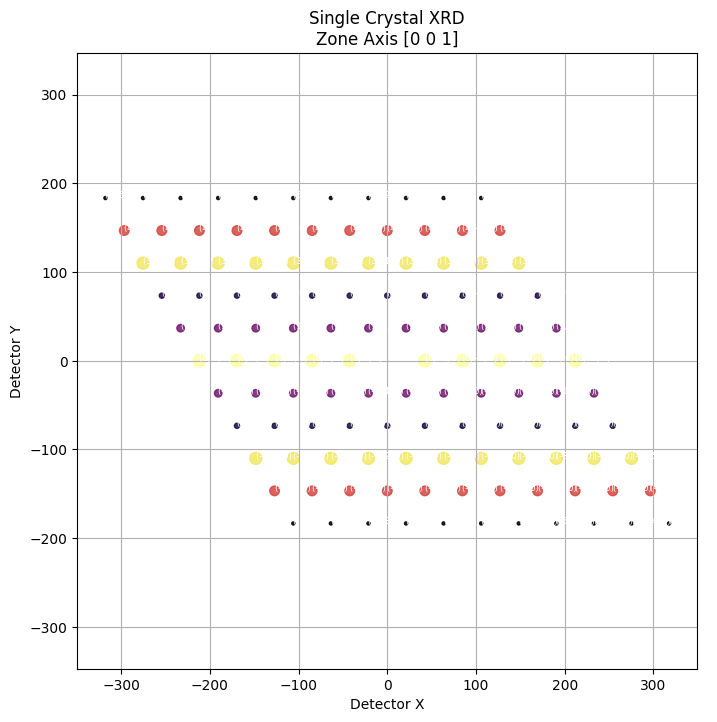

In [21]:
# --------------------------- USER INPUTS ---------------------------
zone_axis     = np.array([0, 0, 1])  # hkl of the crystal zone axis
wavelength    = 0.1665               # incident beam wavelength (angstrom)
camera_length = 1054.0               # sample-to-detector distance (mm)
hkl_max       = 5                    # max |h|,|k|,|l| to search
r_cutoff      = 300                  # only report shells with r < this (mm)
r_bin         = 0.05                 # merge reflections closer than this (mm)


# --------------------------- HELPERS ---------------------------
def clean_float(x):
    """Strip ICSD uncertainty notation, e.g. '5.43053(7)' -> 5.43053."""
    if x is None:
        return None
    x = re.sub(r"\(.*\)", "", str(x).strip())
    return float(x)


def atomic_number(el):
    """Atomic number used as a crude scattering factor (fallback: carbon)."""
    try:
        return gemmi.Element(el).atomic_number
    except Exception:
        return 6


# --------------------------- READ CIF ---------------------------
doc = gemmi.cif.read_file(cif_file)
block = doc.sole_block()

# Space group (try several common CIF keys, default to P 1)
sg_symbol = (
    block.find_value("_symmetry_space_group_name_H-M")
    or block.find_value("_space_group_name_H-M_alt")
    or block.find_value("_symmetry_space_group_name_Hall")
    or "P 1"
)
try:
    spacegroup = gemmi.SpaceGroup(sg_symbol)
except Exception:
    spacegroup = gemmi.SpaceGroup("P 1")

# Lattice parameters
a = clean_float(block.find_value("_cell_length_a"))
b = clean_float(block.find_value("_cell_length_b"))
c = clean_float(block.find_value("_cell_length_c"))
alpha = np.deg2rad(clean_float(block.find_value("_cell_angle_alpha")))
beta  = np.deg2rad(clean_float(block.find_value("_cell_angle_beta")))
gamma = np.deg2rad(clean_float(block.find_value("_cell_angle_gamma")))


# --------------------------- REAL & RECIPROCAL LATTICE ---------------------------
va = np.array([a, 0.0, 0.0])
vb = np.array([b * np.cos(gamma), b * np.sin(gamma), 0.0])
vc_x = c * np.cos(beta)
vc_y = c * (np.cos(alpha) - np.cos(beta) * np.cos(gamma)) / np.sin(gamma)
vc_z = np.sqrt(max(0.0, c**2 - vc_x**2 - vc_y**2))
vc = np.array([vc_x, vc_y, vc_z])

V = np.dot(va, np.cross(vb, vc))                 # unit cell volume
recip = np.array([                                # reciprocal basis (b1, b2, b3)
    2 * np.pi * np.cross(vb, vc) / V,
    2 * np.pi * np.cross(vc, va) / V,
    2 * np.pi * np.cross(va, vb) / V,
])


# --------------------------- ATOMS ---------------------------
x_list = block.find_values("_atom_site_fract_x")
y_list = block.find_values("_atom_site_fract_y")
z_list = block.find_values("_atom_site_fract_z")
el_list = (block.find_values("_atom_site_type_symbol")
           or block.find_values("_atom_site_label"))

if len(x_list) == 0:
    raise RuntimeError("No atomic positions found in CIF")

atoms = []
for x, y, z, el in zip(x_list, y_list, z_list, el_list):
    el = re.sub(r"[^A-Za-z]", "", str(el))        # clean element label
    atoms.append((clean_float(x), clean_float(y), clean_float(z), el))


# --------------------------- DETECTOR BASIS ---------------------------
# Build an in-plane (x_axis, y_axis) frame perpendicular to the zone axis.
z_axis = zone_axis / np.linalg.norm(zone_axis)
tmp = np.array([1.0, 0.0, 0.0])
if abs(np.dot(tmp, z_axis)) > 0.9:
    tmp = np.array([0.0, 1.0, 0.0])
x_axis = np.cross(tmp, z_axis); x_axis /= np.linalg.norm(x_axis)
y_axis = np.cross(z_axis, x_axis)

u, v, w = np.round(10 * zone_axis).astype(int)    # integer zone axis


# --------------------------- HKL LOOP ---------------------------
spots = []
for h, k, l in product(range(-hkl_max, hkl_max + 1),
                       range(-hkl_max, hkl_max + 1),
                       range(-hkl_max, hkl_max + 1)):
    if (h, k, l) == (0, 0, 0):
        continue

    # Skip systematically absent reflections (symmetry)
    try:
        if spacegroup.is_sys_absent(h, k, l):
            continue
    except Exception:
        pass

    # Zone-axis condition: reflection must lie in the plane (h*u + k*v + l*w = 0)
    if (h * u + k * v + l * w) != 0:
        continue

    # Reciprocal-lattice vector for this reflection
    G = h * recip[0] + k * recip[1] + l * recip[2]

    # Structure factor (atomic number as scattering factor)
    F = sum(atomic_number(el) * np.exp(2j * np.pi * (h * x + k * y + l * z))
            for x, y, z, el in atoms)
    intensity = np.abs(F)**2
    if intensity < 1e-6:                           # true extinction
        continue

    # Project G onto the detector plane and convert to a radius (mm)
    R_x = camera_length * wavelength * np.dot(G, x_axis) / (2 * np.pi)
    R_y = camera_length * wavelength * np.dot(G, y_axis) / (2 * np.pi)
    r = np.sqrt(R_x**2 + R_y**2)

    spots.append((R_x, R_y, r, intensity, h, k, l))

if len(spots) == 0:
    raise RuntimeError("No diffraction spots generated")


# --------------------------- NORMALIZE & GROUP ---------------------------
spots = np.array(spots, dtype=object)
xs = np.array([s[0] for s in spots], dtype=float)
ys = np.array([s[1] for s in spots], dtype=float)
rs = np.array([s[2] for s in spots], dtype=float)
Is = np.array([s[3] for s in spots], dtype=float)
hkl = [(s[4], s[5], s[6]) for s in spots]

if np.max(Is) > 0:
    Is = Is / np.max(Is)                           # normalize intensities to 0-1

# Group reflections into radial shells (rounded to r_bin)
groups = defaultdict(list)
for i in range(len(rs)):
    groups[round(rs[i] / r_bin) * r_bin].append(hkl[i])


# --------------------------- REPORT SHELLS ---------------------------
print("\nRadial shells:\n")
for r_key in sorted(groups.keys()):
    if r_key < r_cutoff:
        print(f"r ~ {r_key:.3f}")
        print("  hkl:", sorted(set(groups[r_key])))
        print()


# --------------------------- PLOT ---------------------------
plt.figure(figsize=(8, 8))
plt.scatter(xs, ys, s=80 * Is, c=Is, cmap="inferno", alpha=0.85)
for i in range(len(xs)):
    plt.text(xs[i], ys[i], f"{hkl[i]}", fontsize=6, color="white")
plt.xlabel("Detector X")
plt.ylabel("Detector Y")
plt.title(f"Single Crystal XRD\nZone Axis {zone_axis}")
plt.axis("equal")
plt.grid(True)
plt.show()


## 7. Overlay Predicted Rings on the Image

Take the curated ring distances (in mm), convert to pixels, and draw them on
the loaded image around the detected center. This helps decide whether a spot
is a substrate reflection or a real, highly textured film data point.


In [22]:
# Curated zone-axis ring distances in mm (sapphire wafer example).
# Commented-out values are allowed geometrically but not visible due to
# symmetry extinctions. The hkl groups producing each ring are noted inline.
r = [
#    42.350,
     73.350,   # hkl: [(-2,1,0),(-1,-1,0),(-1,2,0),(1,-2,0),(1,1,0),(2,-1,0)]
#    84.700,
#    112.050,
     127.050,  # hkl: [(-3,0,0),(-3,3,0),(0,-3,0),(0,3,0),(3,-3,0),(3,0,0)]
     146.700,  # hkl: [(-4,2,0),(-2,-2,0),(-2,4,0),(2,-4,0),(2,2,0),(4,-2,0)]
     152.700,  # hkl: [(-4,1,0),(-4,3,0),(-3,-1,0),...]
#    169.400,
     184.600,  # hkl: [(-5,2,0),(-5,3,0),(-3,-2,0),...]
#    194.050,
#    211.750,
#    220.050,
#    224.100,
#    235.800,
#    257.600,
#    264.450,
#    293.400,
#    296.450,
]


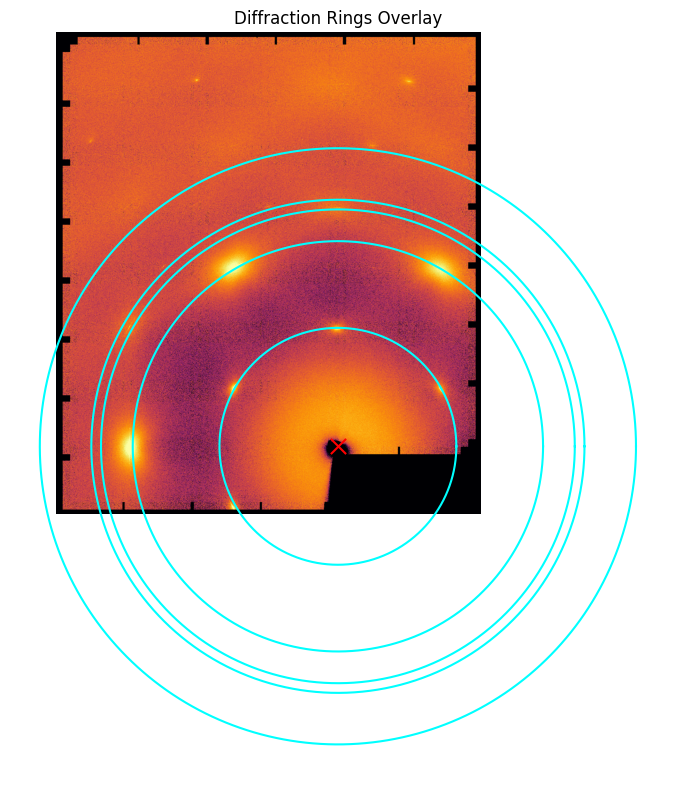

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Diffraction Rings Overlay'}>)

In [23]:
# Convert ring distances from mm to pixels (detector pixel size = 0.172 mm/px)
PIXEL_SIZE_MM = 0.172
radii = [val / PIXEL_SIZE_MM for val in r]

overlay_diffraction_rings(
    display_image,
    center=(center_x, center_y),
    radii=radii,
)


## 8. Extra / Unused Utilities

Helper for computing a ring radius for a known `hkl` from Bragg geometry.
Not used in the main flow, but kept for reference.


In [24]:
def Ring_Distance_Known(lattice_parameter, wavelength, pixel_size,
                        detector_distance, hkl):
    """
    Estimate the ring radius for a known reflection.

    Parameters
    ----------
    lattice_parameter : lattice parameter (angstrom)
    wavelength        : incident beam wavelength (angstrom)
    pixel_size        : physical pixel size (meters)
    detector_distance : sample-to-detector distance (meters)
    hkl               : [h, k, l]

    Returns
    -------
    R_meter, R_pixel  : ring radius in meters and in pixels
    """
    sum_hkl = sum(i**2 for i in hkl)
    d_hkl = math.sqrt(sum_hkl)
    R_meter = detector_distance * math.tan(
        2 * math.asin(wavelength * d_hkl / 2 / lattice_parameter)
    )
    R_pixel = R_meter / pixel_size
    return R_meter, R_pixel
